# K-Nearest Neighbor Lab
Read over the sklearn info on [nearest neighbor learners](https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors-classification)




In [ ]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import numpy as np
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 1 K-Nearest Neighbor (KNN) algorithm

### 1.1 Basic KNN Classification

Learn the [Glass data set](https://archive.ics.uci.edu/dataset/42/glass+identification) using [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier) with default parameters.
- Randomly split your data into train/test.  Anytime we don't tell you specifics (such as what percentage is train vs test) choose your own reasonable values
- Give typical train and test set accuracies after running with different random splits
- Print the output probabilities for a test set (predict_proba)
- Try it with different p values (Minkowskian exponent) and discuss any differences

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
glass_identification = fetch_ucirepo(id=42)

# data (as pandas dataframes)
X = glass_identification.data.features
y = glass_identification.data.targets

# metadata
print(glass_identification.metadata)

# variable information
print(glass_identification.variables)

{'uci_id': 42, 'name': 'Glass Identification', 'repository_url': 'https://archive.ics.uci.edu/dataset/42/glass+identification', 'data_url': 'https://archive.ics.uci.edu/static/public/42/data.csv', 'abstract': 'From USA Forensic Science Service; 6 types of glass; defined in terms of their oxide content (i.e. Na, Fe, K, etc)', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 214, 'num_features': 9, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Type_of_glass'], 'index_col': ['Id_number'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1987, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5WW2P', 'creators': ['B. German'], 'intro_paper': None, 'additional_info': {'summary': 'Vina conducted a comparison test of her rule-based system, BEAGLE, the nearest-neighbor algorithm, and discriminant analysis.  BEAGLE is a product available through VRS Consulting, In

In [ ]:
# Learn the glass data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
knn = KNeighborsClassifier(p=1)
knn.fit(X_train, y_train)
train_accuracy = knn.score(X_train, y_train)
test_accuracy = knn.score(X_test, y_test)
print(f"train accuracy: {train_accuracy}")
print(f" test accuracy: {test_accuracy}")
print(knn.predict_proba(X_test))

train accuracy: 0.7894736842105263
 test accuracy: 0.6744186046511628
[[0.6 0.  0.4 0.  0.  0. ]
 [0.4 0.4 0.2 0.  0.  0. ]
 [0.4 0.6 0.  0.  0.  0. ]
 [0.4 0.6 0.  0.  0.  0. ]
 [0.4 0.  0.6 0.  0.  0. ]
 [0.  0.  0.  0.  0.  1. ]
 [0.  0.  0.  0.  0.  1. ]
 [1.  0.  0.  0.  0.  0. ]
 [0.8 0.2 0.  0.  0.  0. ]
 [0.4 0.  0.6 0.  0.  0. ]
 [0.  0.4 0.  0.  0.6 0. ]
 [0.8 0.  0.2 0.  0.  0. ]
 [0.  1.  0.  0.  0.  0. ]
 [0.8 0.2 0.  0.  0.  0. ]
 [0.4 0.  0.6 0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [0.  1.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  1. ]
 [0.2 0.8 0.  0.  0.  0. ]
 [0.  0.4 0.  0.  0.6 0. ]
 [0.6 0.4 0.  0.  0.  0. ]
 [0.2 0.6 0.2 0.  0.  0. ]
 [0.2 0.8 0.  0.  0.  0. ]
 [0.  1.  0.  0.  0.  0. ]
 [0.2 0.4 0.2 0.  0.  0.2]
 [0.6 0.4 0.  0.  0.  0. ]
 [0.4 0.  0.  0.  0.6 0. ]
 [0.  0.  0.  0.  0.  1. ]
 [0.  1.  0.  0.  0.  0. ]
 [0.2 0.6 0.2 0.  0.  0. ]
 [0.  0.  0.  0.4 0.  0.6]
 [1.  0.  0.  0.  0.  0. ]
 [0.4 0.6 0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  1. ]
 [1.  0.  0.

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


#### Discussion
What were your accuracies or output probabilities and how did different hyperparameter values affect the outcome? Discuss the differences you see.

The train accuracy ended up at about 79% and the test accuracy about 67%. Those accuracy numbers stay relatively similar with different train/test splits. Changing the p value seemed relatively inconsequential, with spikes in accuracy at around 1 and 10. Using the default parameters and a p value of 1 essentially gave us a model that is 2/3 accurate.



## 2 KNN Classification with normalization and distance weighting

Use the [magic telescope](https://axon.cs.byu.edu/data/uci_class/MagicTelescope.arff) dataset

### 2.1 - Without Normalization or Distance Weighting
- Do random 80/20 train/test splits each time
- Run with k=3 and *without* distance weighting and *without* normalization
- Show train and test set accuracy

In [ ]:
# Learn magic telescope data

# fetch dataset
magic_gamma_telescope = fetch_ucirepo(id=159)

# data (as pandas dataframes)
X = magic_gamma_telescope.data.features
y = magic_gamma_telescope.data.targets

# metadata
print(magic_gamma_telescope.metadata)

# variable information
print(magic_gamma_telescope.variables)


{'uci_id': 159, 'name': 'MAGIC Gamma Telescope', 'repository_url': 'https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope', 'data_url': 'https://archive.ics.uci.edu/static/public/159/data.csv', 'abstract': 'Data are MC generated to simulate registration of high energy gamma particles in an atmospheric Cherenkov telescope', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 19020, 'num_features': 10, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2004, 'last_updated': 'Tue Dec 19 2023', 'dataset_doi': '10.24432/C52C8B', 'creators': ['R. Bock'], 'intro_paper': None, 'additional_info': {'summary': "The data are MC generated (see below) to simulate registration of high energy gamma particles in a ground-based atmospheric Cherenkov gamma telescope using the imaging technique. Cherenkov gamm

In [ ]:
# Learn the magic telescope data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)
knn = KNeighborsClassifier(n_neighbors=3, weights='uniform')
knn.fit(X_train, y_train)
train_accuracy = knn.score(X_train, y_train)
test_accuracy = knn.score(X_test, y_test)
print(f"train accuracy: {train_accuracy}")
print(f" test accuracy: {test_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


train accuracy: 0.8874868559411146
 test accuracy: 0.7923238696109358


#### Discussion
What did you observe in your results?

Running a KNN classifier with 3 neighbors and uniform weights resulted in a relatively accurate model, with about 89% accuracy on the training set and about 81% accuracy on the test set.

### 2.2 With Normalization
- Try it with k=3 without distance weighting but *with* normalization of input features.  You may use any reasonable normalization approach (e.g. standard min-max normalization between 0-1, z-transform, etc.)

In [ ]:
# Train/Predict with normalization
from sklearn import preprocessing

normalized_X_train = preprocessing.normalize(X_train)
normalized_X_test = preprocessing.normalize(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3, weights='uniform')
knn.fit(normalized_X_train, y_train)
train_accuracy = knn.score(normalized_X_train, y_train)
test_accuracy = knn.score(normalized_X_test, y_test)
print(f"train accuracy: {train_accuracy}")
print(f" test accuracy: {test_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


train accuracy: 0.8643533123028391
 test accuracy: 0.7691903259726603


#### Discussion
Discuss the results of using normalized data vs. unnormalized data

Using normalized data actually decreased the accuracy of the KNN classifier in this case. It seems like the uniform weights may have an influence upon the lack of benefit of normalization.



### 2.3 With Distance Weighting
- Try it with k=3 and with distance weighting *and* normalization

In [ ]:
#Train/Precdict with normalization and distance weighting
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn.fit(normalized_X_train, y_train)
train_accuracy = knn.score(normalized_X_train, y_train)
test_accuracy = knn.score(normalized_X_test, y_test)
print(f"train accuracy: {train_accuracy}")
print(f" test accuracy: {test_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


train accuracy: 1.0
 test accuracy: 0.7715562565720294


#### Discussion
Comparison and discuss the differences you see with distance weighting and normalization vs without.

Adding distance weighting with normalized features pushed our train accuracy to 100%. The test accuracy did not improve, but there is an obvious benefit to introducing distance weighting with normalized features.

### 2.4 Different k Values
- Using your normalized data with distance weighting, create one graph with classification accuracy on the test set on the y-axis and k values on the x-axis.
- Use values of k from 1 to 15.  Use the same train/test split for each.

In [ ]:
# Calculate and Graph classification accuracy vs k values
train_scores = []
test_scores = []
for k in range(1,15+1):
  knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
  knn.fit(normalized_X_train, y_train)
  train_accuracy = knn.score(normalized_X_train, y_train)
  test_accuracy = knn.score(normalized_X_test, y_test)
  train_scores.append(train_accuracy)
  test_scores.append(test_accuracy)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

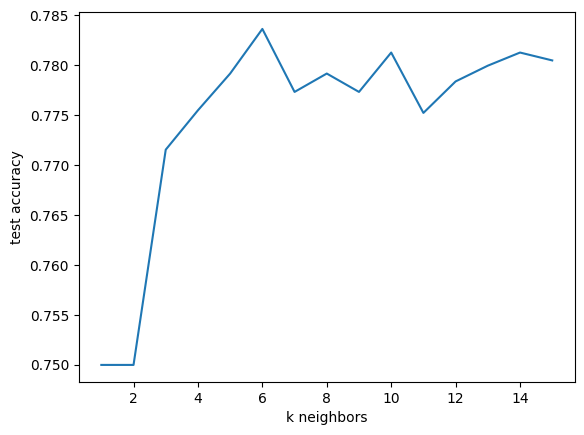

In [ ]:
plt.plot(range(1,15+1), test_scores)
plt.xlabel('k neighbors')
plt.ylabel('test accuracy')
plt.show()

#### Discussion
How do the k values affect your results?

There is a strong improvement in the accuracy of the model up to about 6 neighbors, after which there is no significant improvement. There is also some variation in the performance of the model after k > 6. It seems like the optimal number of neighbors is about 6 for this dataset and set of parameters.

## 3 KNN Regression with normalization and distance weighting

Use the [sklean KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor) on the [housing price prediction](https://axon.cs.byu.edu/data/uci_regression/housing.arff) problem.  
### 3.1 Ethical Data
Note this data set has an example of an inappropriate input feature which we discussed.  State which feature is inappropriate and discuss why.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("altavish/boston-housing-dataset")
print("Path to dataset files:", path)

100%|██████████| 11.7k/11.7k [00:00<00:00, 11.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/altavish/boston-housing-dataset/versions/1


In [ ]:
df = bos_house = pd.read_csv('/root/.cache/kagglehub/datasets/altavish/boston-housing-dataset/versions/1/HousingData.csv')
new_names = {
    "crim": "CrimeRatePerCapita",
    "zn": "ResidentialZoneProp",
    "indus": "NonRetailLandProp",
    "chas": "CharlesRiverProximity",
    "nox": "NitricOxideConcentration",
    "rm": "AvgRoomsPerDwelling",
    "age": "Pre1940OwnerProp",
    "dis": "EmploymentCenterDist",
    "rad": "HighwayAccessIndex",
    "tax": "PropertyTaxRate",
    "ptratio": "PupilTeacherRatio",
    "b": "BlackPopulationIndex",
    "lstat": "LowIncomePopulation",
    "medv": "MedianHomeValue"
}
df.columns = df.columns.str.lower()
df.rename(columns=new_names, inplace=True)
df.describe()

,CrimeRatePerCapita,ResidentialZoneProp,NonRetailLandProp,CharlesRiverProximity,NitricOxideConcentration,AvgRoomsPerDwelling,Pre1940OwnerProp,EmploymentCenterDist,HighwayAccessIndex,PropertyTaxRate,PupilTeacherRatio,BlackPopulationIndex,LowIncomePopulation,MedianHomeValue
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


#### Discussion
Discuss the innapropriate feature. Which one and why?

The BlackPopulationIndex feature seems inappropriate to use as input for a model. In predicting housing prices, we end up including a feature that promotes racist decisions. We are essentially assuming that racial segregation influences house prices, which should not be a factor in such decisions.

In [ ]:
df.drop('BlackPopulationIndex', axis=1, inplace = True)
df.drop('CharlesRiverProximity', axis=1, inplace = True) #dropping categorical feature
df.columns

Index(['CrimeRatePerCapita', 'ResidentialZoneProp', 'NonRetailLandProp',
       'NitricOxideConcentration', 'AvgRoomsPerDwelling', 'Pre1940OwnerProp',
       'EmploymentCenterDist', 'HighwayAccessIndex', 'PropertyTaxRate',
       'PupilTeacherRatio', 'LowIncomePopulation', 'MedianHomeValue'],
      dtype='object')

### 3.2 - KNN Regression
- Do random 80/20 train/test splits each time
- Run with k=3
- Print the score (coefficient of determination) and Mean Absolute Error (MAE) for the train and test set for the cases of
  - No input normalization and no distance weighting
  - Normalization and no distance weighting
  - Normalization and distance weighting
- Normalize inputs features where needed but do not normalize the output

In [ ]:
df.dropna(axis=0, inplace=True) #dropping observations with missing values

In [ ]:
X = df.drop('MedianHomeValue', axis=1)
y = df['MedianHomeValue']

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
# Learn and experiment with housing price prediction data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

# no normalization or weighting
knn = KNeighborsRegressor(n_neighbors=3, weights='uniform')
knn.fit(X_train, y_train)

# train metrics
train_accuracy = knn.score(X_train, y_train)
train_mae = mean_absolute_error(knn.predict(X_train), y_train)
print(f"train accuracy: {train_accuracy}")
print(f"train MAE: {train_mae}")

# test metrics
test_accuracy = knn.score(X_test, y_test)
test_mae = mean_absolute_error(knn.predict(X_test), y_test)
print(f"test accuracy: {test_accuracy}")
print(f"test MAE: {test_mae}")

train accuracy: 0.7782854517027573
train MAE: 2.783638211382114
test accuracy: 0.5698235293963736
test MAE: 4.443373493975904


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

# normalization and no weighting
normalized_X_train = preprocessing.normalize(X_train)
normalized_X_test = preprocessing.normalize(X_test)
knn = KNeighborsRegressor(n_neighbors=3, weights='uniform')
knn.fit(normalized_X_train, y_train)

# train metrics
train_accuracy = knn.score(normalized_X_train, y_train)
train_mae = mean_absolute_error(knn.predict(normalized_X_train), y_train)
print(f"train accuracy: {train_accuracy}")
print(f"train MAE: {train_mae}")

# test metrics
test_accuracy = knn.score(normalized_X_test, y_test)
test_mae = mean_absolute_error(knn.predict(normalized_X_test), y_test)
print(f"test accuracy: {test_accuracy}")
print(f"test MAE: {test_mae}")

train accuracy: 0.7983011289832024
train MAE: 2.5909552845528454
test accuracy: 0.5563203558646789
test MAE: 4.223694779116465


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# normalization and weighting
normalized_X_train = preprocessing.normalize(X_train)
normalized_X_test = preprocessing.normalize(X_test)
knn = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn.fit(normalized_X_train, y_train)

# train metrics
train_accuracy = knn.score(normalized_X_train, y_train)
train_mae = mean_absolute_error(knn.predict(normalized_X_train), y_train)
print(f"train accuracy: {train_accuracy}")
print(f"train MAE: {train_mae}")

# test metrics
test_accuracy = knn.score(normalized_X_test, y_test)
test_mae = mean_absolute_error(knn.predict(normalized_X_test), y_test)
print(f"test accuracy: {test_accuracy}")
print(f"test MAE: {test_mae}")

train accuracy: 1.0
train MAE: 0.0
test accuracy: 0.5571426038794871
test MAE: 3.6891700371085614


#### Discussion
Discuss your results. How did the hyperparameters affect your results? Discuss each one and combinations of each.

Normalizing the features and adding distance weighting increased the train accuracy, but did not do much to increase the test accuracy. The mean absolute error, however, was lower when using both distance weighting and normalized features. It seems like there is something else we need to optimize.

### 3.3  Different k Values
- Using housing with normalized data and distance weighting, create one graph with MAE on the test set on the y-axis and k values on the x-axis
- Use values of k from 1 to 15.  Use the same train/test split for each.

Text(0, 0.5, 'test accuracy')

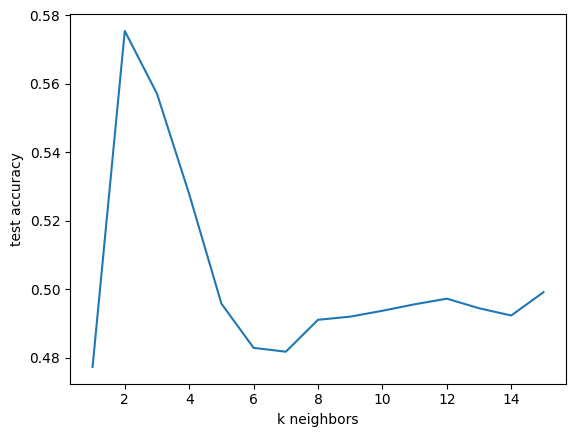

In [ ]:
# Learn and graph for different k values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# normalization and weighting
normalized_X_train = preprocessing.normalize(X_train)
normalized_X_test = preprocessing.normalize(X_test)
knn = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn.fit(normalized_X_train, y_train)

test_scores = []
for k in range(1,15+1):
  knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
  knn.fit(normalized_X_train, y_train)
  test_accuracy = knn.score(normalized_X_test, y_test)
  test_scores.append(test_accuracy)

plt.plot(range(1,15+1), test_scores)
plt.xlabel('k neighbors')
plt.ylabel('test accuracy')

#### Discussion
How did the k values affect your results for this dataset? How does that compare to your previous work in this lab?

There is a spike in accuracy at 2 or 3 neighbors, then a sharp drop in accuracy afterwards. This is a bit different from the previous results in the lab. Before we saw that accuracy remained high but didn't improve. Here, instead, accuracy plummets after a certain threshold.

## 4. KNN with nominal and real data

- Use the [lymph dataset](https://axon.cs.byu.edu/data/uci_class/lymph.arff)
- Use a 80/20 split of the data for the training/test set
- This dataset has both continuous and nominal attributes
- Implement a distance metric which uses Euclidean distance for continuous features and 0/1 distance for nominal. Hints:
    - Write your own distance function (e.g. mydist) and use clf = KNeighborsClassifier(metric=mydist)
    - Change the nominal features in the data set to integer values since KNeighborsClassifier expects numeric features. I used Label_Encoder on the nominal features.
    - Keep a list of which features are nominal which mydist can use to decide which distance measure to use
    - There was an occasional bug in SK version 1.3.0 ("Flags object has no attribute 'c_contiguous'") that went away when I upgraded to the lastest SK version 1.3.1
- Use your own choice for k and other parameters

In [ ]:
# fetch dataset
lymphography = fetch_ucirepo(id=63)

# data (as pandas dataframes)
X = lymphography.data.features
y = lymphography.data.targets

# metadata
print(lymphography.metadata)

# variable information
print(lymphography.variables)


{'uci_id': 63, 'name': 'Lymphography', 'repository_url': 'https://archive.ics.uci.edu/dataset/63/lymphography', 'data_url': 'https://archive.ics.uci.edu/static/public/63/data.csv', 'abstract': 'This lymphography domain was obtained from the University Medical Centre, Institute of Oncology, Ljubljana, Yugoslavia.  (Restricted access)', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 148, 'num_features': 19, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Sat Mar 09 2024', 'dataset_doi': '10.24432/C54598', 'creators': ['M. Zwitter', 'M. Soklic'], 'intro_paper': None, 'additional_info': {'summary': 'This is one of three domains provided by the Oncology Institute that has repeatedly appeared in the machine learning literature. (See also breast-cancer and primary-tumor

In [ ]:
X.head()

,lymphatics,block of affere,bl. of lymph. c,bl. of lymph. s,by pass,extravasates,regeneration of,early uptake in,lym.nodes dimin,lym.nodes enlar,changes in lym,defect in node,changes in node,changes in node,changes in stru,special forms,dislocation of,exclusion of no,no. of nodes in
0,4,2,1,1,1,1,1,2,1,2,2,2,4,4,1,1,2,2,NaN
1,3,2,1,1,2,2,1,2,1,3,3,2,3,3,2,2,2,2,NaN
2,3,2,2,2,2,2,2,2,1,4,3,3,4,4,3,2,2,7,NaN
3,3,1,1,1,1,2,1,2,1,3,3,4,4,4,3,1,2,6,NaN
4,3,1,1,1,1,1,1,1,1,2,2,4,3,3,1,2,2,1,NaN


In [ ]:
X = pd.get_dummies(X, columns=['lymphatics',
                               'block of affere',
                               'bl. of lymph. c',
                               'bl. of lymph. s',
                               'by pass',
                               'extravasates',
                               'regeneration of',
                               'early uptake in',
                               'changes in lym',
                               'defect in node',
                               'changes in node',
                               'changes in stru',
                               'special forms',
                               'dislocation of',
                               'exclusion of no'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X = X.apply(le.fit_transform)

In [ ]:
X.head()

,lym.nodes dimin,lym.nodes enlar,no. of nodes in,lymphatics_1,lymphatics_2,lymphatics_3,lymphatics_4,block of affere_1,block of affere_2,bl. of lymph. c_1,...,dislocation of_1,dislocation of_2,exclusion of no_1,exclusion of no_2,exclusion of no_3,exclusion of no_4,exclusion of no_5,exclusion of no_6,exclusion of no_7,exclusion of no_8
0,0,1,0,0,0,0,1,0,1,1,...,0,1,0,1,0,0,0,0,0,0
1,0,2,0,0,0,1,0,0,1,1,...,0,1,0,1,0,0,0,0,0,0
2,0,3,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
3,0,2,0,0,0,1,0,1,0,1,...,0,1,0,0,0,0,0,1,0,0
4,0,1,0,0,0,1,0,1,0,1,...,0,1,1,0,0,0,0,0,0,0


In [ ]:
X.columns

51


In [ ]:
X.columns.get_loc('lym.nodes dimin')

0

In [ ]:
X.columns.get_loc('lym.nodes enlar')

1

In [ ]:
X.columns.get_loc('no. of nodes in')

2

In [ ]:
# Train/Predict lymph with your own distance metric
def custom_distance(point1, point2):
  # define the nominal and continuous features
  indices_for_01 = [i for i in range(3,51)]
  indices_for_L2 = [0,1,2]
  point1_L2 = point1[indices_for_L2]
  point2_L2 = point2[indices_for_L2]
  point1_01 = point1[indices_for_01]
  point2_01 = point2[indices_for_01]

  # perform L2 distance for continuous and 0 or 1 for nominal
  L2_distance = np.linalg.norm(point1_L2 - point2_L2)
  nominal_distance = sum(abs(np.subtract(point1_01,point2_01)))
  return L2_distance + nominal_distance

X_train, X_test, y_train, y_test = train_test_split(X,y)

knn = KNeighborsClassifier(n_neighbors=10, weights='distance', metric=custom_distance)
knn.fit(X_train, y_train)
train_accuracy = knn.score(X_train, y_train)
test_accuracy = knn.score(X_test, y_test)
print(f"train accuracy: {train_accuracy}")
print(f" test accuracy: {test_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


train accuracy: 1.0
 test accuracy: 0.8918918918918919


#### Discussion
Explain your distance metric and discuss your results

My distance metric works by separating the factors that are continuous and the factors that are nominal. That is the purpose of finding the indices of said factors and selecting those columns from the data that is input. L2 norms are calculated for the continuous factors while the nominal ones are either 1 or 0.

The model works relatively well, having perfect accuracy on the train set and about 90% accuracy on the test set. It seemed like more neighbors increased the accuracy of the model and did not have a significant detriment to the model's performance.